In [4]:
import tensorflow as tf
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import numpy as np
import PIL
import mlflow
import mlflow.tensorflow


from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [5]:
#Download the Kaggle "amazon product images" dataset

path = kagglehub.dataset_download("wai157/amazon-product-images")

#updating the file path
data_path = os.path.join(path, "data")
print("Path to dataset files:", data_path)


Path to dataset files: C:\Users\ugniu\.cache\kagglehub\datasets\wai157\amazon-product-images\versions\1\data


In [6]:
# setting up the parameters for the images
batch_size = 32
img_height = 64
img_width = 64


In [7]:
# Creating datasets for training, testing and validation
train_data = tf.keras.utils.image_dataset_from_directory(
os.path.join(data_path, "train"),
    image_size=(img_width,img_height),
    batch_size=batch_size)

test_data = tf.keras.utils.image_dataset_from_directory(
os.path.join(data_path, "test"),
    image_size=(img_width,img_height),
    batch_size=batch_size)

val_data = tf.keras.utils.image_dataset_from_directory(
os.path.join(data_path, "val"),
    image_size=(img_width,img_height),
    batch_size=batch_size)

# Saving the class names before optimization
class_names = train_data.class_names
print(f"all categories:{class_names}")

Found 40000 files belonging to 10 classes.
Found 5000 files belonging to 10 classes.
Found 5000 files belonging to 10 classes.
list of names ['beauty_products', 'electronics', 'fashion', 'fitness_equipments', 'furniture', 'home_appliances', 'kitchenware', 'musical_instruments', 'study_things', 'toys']


In [9]:
#Data augmentation to decrease overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)])

In [10]:
# Opitmizing the performance of the model

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
# Building the Model

num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])


model.summary()

C:\Users\ugniu\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 549,290 (2.10 MB)

 Trainable params: 549,290 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compiling the model

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [20]:
#Training the model

#Using 10 epochs and 64x64, because the cpu is use is slow

epochs=10

#MLflow metric tracking
mlflow.set_experiment("item_classifier")
mlflow.tensorflow.autolog()

#Model training
with mlflow.start_run():
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        verbose=1)


    test_loss, test_accuracy = model.evaluate(test_data)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_accuracy)



2026/05/26 11:42:23 INFO mlflow.tracking.fluent: Experiment with name 'item_classifier' does not exist. Creating a new experiment.


Epoch 1/10
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9662 - loss: 0.1030

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.9562 - loss: 0.1316 - val_accuracy: 0.4260 - val_loss: 5.2532
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9566 - loss: 0.1338 - val_accuracy: 0.4254 - val_loss: 5.3088
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.9581 - loss: 0.1278 - val_accuracy: 0.4284 - val_loss: 5.3757
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9601 - loss: 0.1259

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9571 - loss: 0.1336 - val_accuracy: 0.4216 - val_loss: 5.1934
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9592 - loss: 0.1216 - val_accuracy: 0.4176 - val_loss: 5.3018
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9649 - loss: 0.1048

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9574 - loss: 0.1284 - val_accuracy: 0.4206 - val_loss: 5.1932
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9604 - loss: 0.1190 - val_accuracy: 0.4342 - val_loss: 5.4451
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.9582 - loss: 0.1216 - val_accuracy: 0.4230 - val_loss: 5.5150
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.9602 - loss: 0.1194 - val_accuracy: 0.4280 - val_loss: 5.7008
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.9622 - loss: 0.1102 - val_accuracy: 0.4240 - val_loss: 5.5113
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


2026/05/26 11:48:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4336 - loss: 5.4871


In [21]:
#save the model to a separate folder
os.makedirs("models", exist_ok=True)
model.save("models/image_classifier.keras")

#check whether the model was saved successfully
for file in os.listdir("models"):
    print(file)

image_classifier.keras


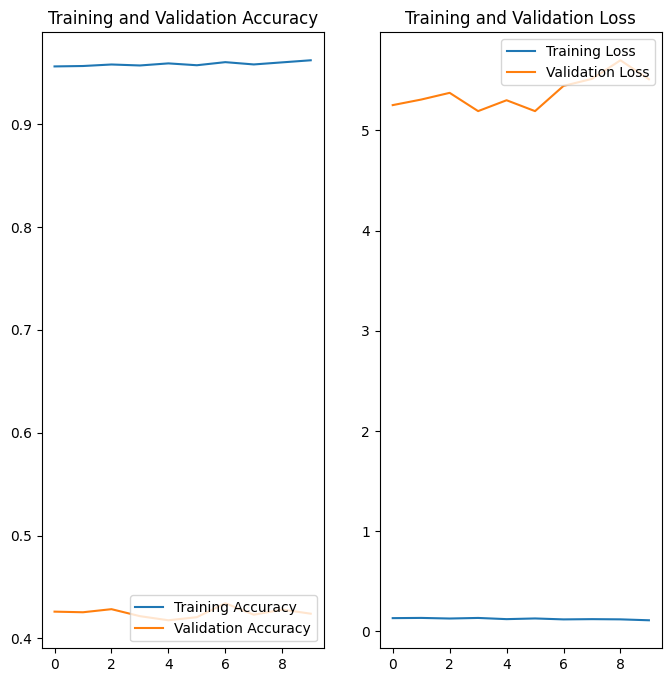

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()